### Code 04 - Hits differences analysis from Olivier Screen

In [1]:
import pandas as pd
from matplotlib_venn import venn2
import matplotlib.pyplot as plt
import glob
import os

In [2]:
# DrugZ TKOv3
hits_original = pd.read_csv("../../data/result_gene_hits_change/tkov3_olivieri_paper/MLN4924_output_original.txt", sep = "\t")
hits_refined = pd.read_csv("../../data/result_gene_hits_change/tkov3_olivieri_paper/MLN4924_output_refined.txt", sep = "\t")

# Filter hits by selecting fdr_synth < 0.15, normZ < -3 and normZ > 6 (Olivieri et al., 2021)
hits_original = hits_original[((hits_original["fdr_synth"] < 0.15) & (hits_original["normZ"] < -3)) | ((hits_original["fdr_supp"] < 0.15) & (hits_original["normZ"] > 6))]
hits_refined = hits_refined[((hits_refined["fdr_synth"] < 0.15) & (hits_refined["normZ"] < -3)) | ((hits_refined["fdr_supp"] < 0.15) & (hits_refined["normZ"] > 6))]

In [28]:
# comparison between hits

def venn_diagram(df_1, df_2, name_1, name_2, colors=("red","blue"), fontsize=12):
    edges_set_1 = set(df_1['GENE'])
    edges_set_2 = set(df_2['GENE'])

    plt.figure(figsize=(5, 5))
    v = venn2([edges_set_1, edges_set_2], (str(name_1), str(name_2)), set_colors=colors)

    for text in v.set_labels:
        if text is not None:
            text.set_fontsize(fontsize)
    for text in v.subset_labels:
        if text is not None:
            text.set_fontsize(max(13, fontsize - 2))

    plt.title("Hits comparison RPE1-treated MLN4924 (TKOv3 library)")
    plt.show()

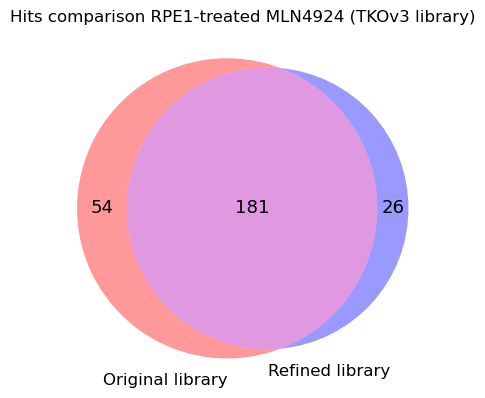

In [29]:
venn_diagram(hits_original, hits_refined, "Original library", "Refined library")

In [ ]:
diff = set(hits_original["GENE"]) - set(hits_refined["GENE"])
diff

In [ ]:
diff = set(hits_refined["GENE"]) - set(hits_original["GENE"])
diff

### Hits difference analysis from Olivieri Screen

In [3]:
path = "../../data/result_gene_hits_change/tkov3_olivieri_paper/"

all_files = glob.glob(os.path.join(path, "*_output_*.txt"))

drug_names = sorted({os.path.basename(f).split("_output_")[0] for f in all_files})
results = []

for drug in drug_names:
     # Build file paths safely
    original_file = os.path.join(path, f"{drug}_output_original.txt")
    refined_file = os.path.join(path, f"{drug}_output_refined.txt")

    # Read files
    hits_original = pd.read_csv(original_file, sep="\t")
    hits_refined = pd.read_csv(refined_file, sep="\t")

    # Filter FDR < 0.5
    hits_original = hits_original[((hits_original["fdr_synth"] < 0.15) & (hits_original["normZ"] < -3)) | ((hits_original["fdr_supp"] < 0.15) & (hits_original["normZ"] > 6))]
    hits_refined = hits_refined[((hits_refined["fdr_synth"] < 0.15) & (hits_refined["normZ"] < -3)) | ((hits_refined["fdr_supp"] < 0.15) & (hits_refined["normZ"] > 6))]

    # Convert to sets
    set_original = set(hits_original["GENE"])
    set_refined  = set(hits_refined["GENE"])

    # Exclusive genes
    original = set_original - set_refined
    refined = set_refined - set_original

    # Overlap
    overlap = set_original & set_refined   # intersection (shared genes)
    # union_genes = set_orig | set_ref   # if you actually want union count

    # Store result
    results.append({
        "drug": drug,
        "total_original_hits": len(set_original),
        "total_refined_hits": len(set_refined),
        "overlap_hits": len(overlap),
        "hits_only_in_original": len(original),
        "hits_only_in_refined": len(refined),
        # "n_union": len(union_genes)   # optional
    })

In [4]:
data = pd.DataFrame(results)
data

,drug,total_original_hits,total_refined_hits,overlap_hits,hits_only_in_original,hits_only_in_refined
0,AZD6738,94,79,70,24,9
1,BPDE,46,39,34,12,5
2,Bleomycin,25,21,16,9,5
3,CD437,105,90,83,22,7
4,CPT-2,139,118,108,31,10
5,Calicheamicin,7,6,6,1,0
6,Cisplatin,116,103,95,21,8
7,Cisplatin-3,139,118,107,32,11
8,Duocarmycin,43,45,36,7,9
9,Formaldehyde,49,46,38,11,8
